<a href="https://colab.research.google.com/github/Sagar-Ramajinappa/virtual-work-lab-task02/blob/main/Untitled12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Shape:
(5000, 14)

First 5 Records:
   CustomerID  Gender  Age  Tenure  MonthlyCharges  TotalCharges ContractType  \
0      100000    Male   61      15             871         13065       Yearly   
1      100001    Male   53       5            2369         11845      Monthly   
2      100002  Female   35      36            2031         73116      Monthly   
3      100003  Female   56      44            1770         77880    Quarterly   
4      100004  Female   54      69            1500        103500      Monthly   

  PaymentMethod  SupportTickets  LoginFrequency  AvgSessionTime  \
0   Credit Card               4               1           72.91   
1    Debit Card               1               1           30.35   
2           UPI               0              26          115.08   
3   Credit Card               1               4           88.92   
4   Credit Card               6               4           10.27   

   LastActivityDays  SatisfactionScore Churn  
0                2

/tmp/ipykernel_3685/3303314683.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3685/3303314683.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

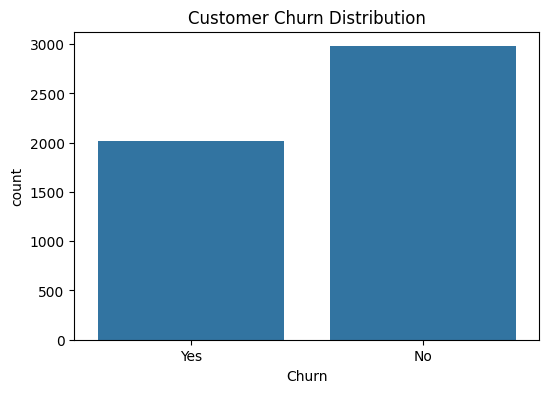


Churn Rate: 40.44%


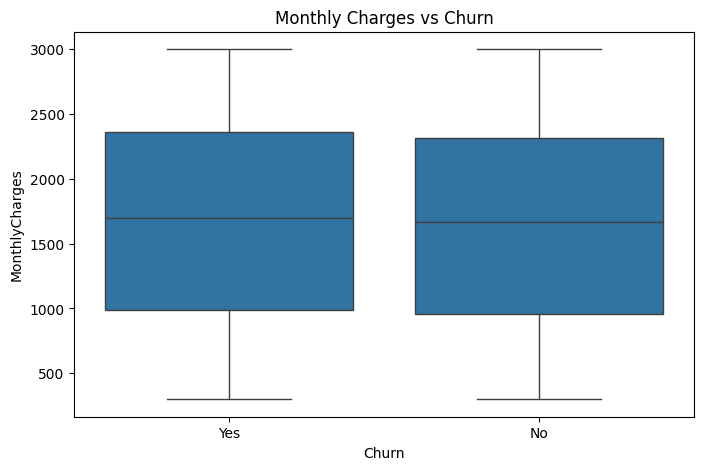

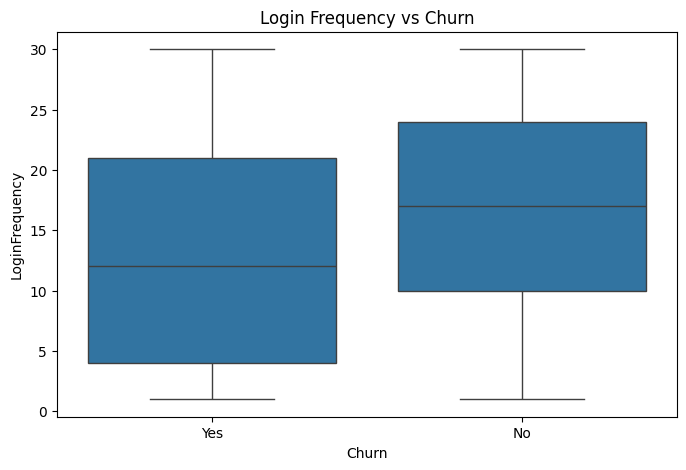

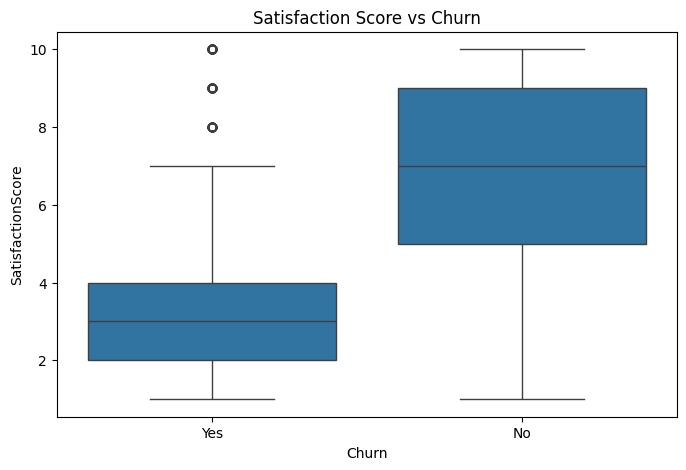

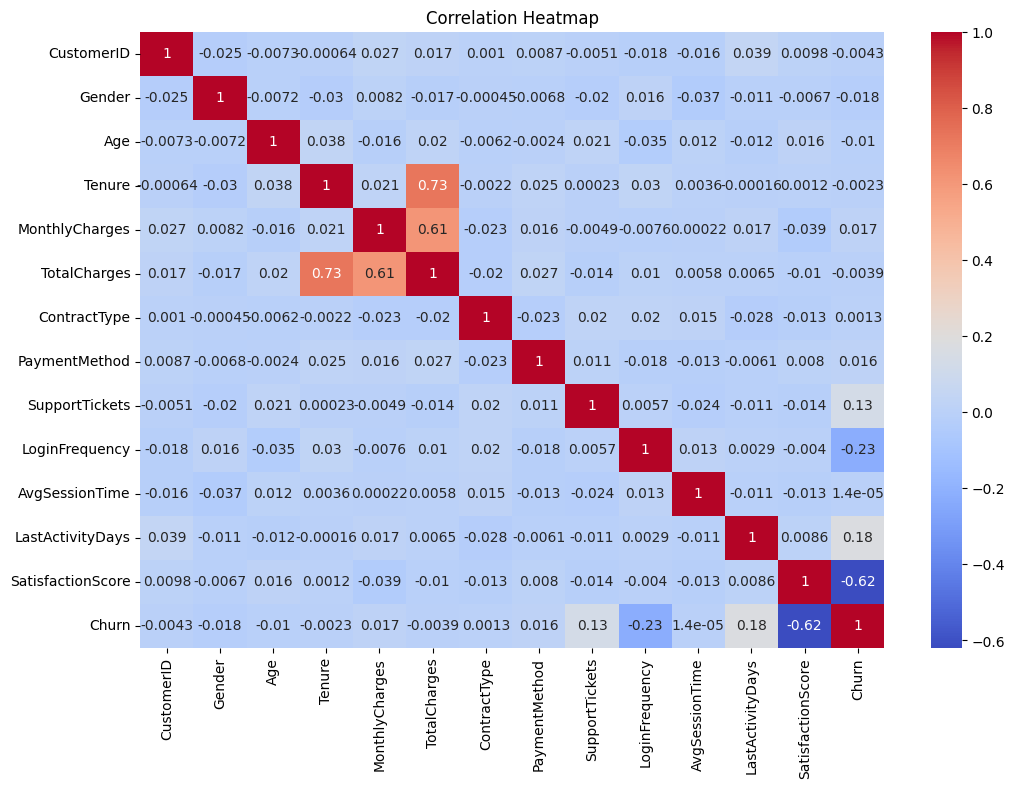


LOGISTIC REGRESSION


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.836

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       604
           1       0.81      0.77      0.79       396

    accuracy                           0.84      1000
   macro avg       0.83      0.82      0.83      1000
weighted avg       0.84      0.84      0.84      1000


Confusion Matrix
[[533  71]
 [ 93 303]]

RANDOM FOREST
Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       604
           1       1.00      1.00      1.00       396

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Top Important Features
              Feature  Importance
12  SatisfactionScore    0.547205
9      LoginFrequency    0.189688
11   LastActivityDays    0.106601
8      SupportTickets    0.065456
10     AvgSessionTim

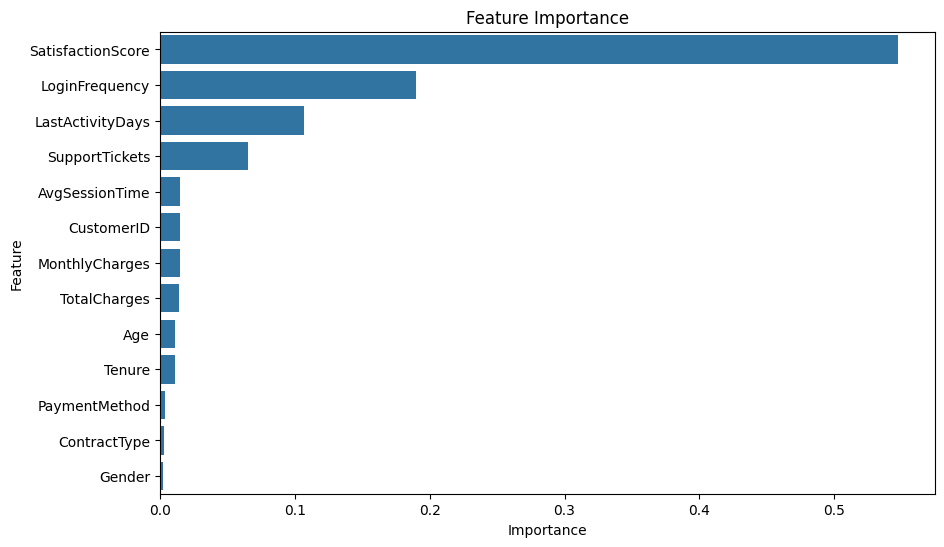


Clean Dataset Saved

===== BUSINESS INSIGHTS =====

1. Customers with low login frequency
   are more likely to churn.

2. Low satisfaction score strongly
   impacts churn.

3. High inactivity period is a major
   churn indicator.

4. Customers raising many support
   tickets have higher churn risk.

5. Retention campaigns should target:
   - Low engagement users
   - Unsatisfied customers
   - Inactive customers



In [1]:
# ==========================
# CUSTOMER CHURN ANALYSIS
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("customer_churn_5000.csv")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

# ==========================
# DATA CLEANING
# ==========================

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nDuplicates Removed")
print("New Shape:", df.shape)

# ==========================
# BASIC INFORMATION
# ==========================

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ==========================
# CHURN DISTRIBUTION
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.savefig("churn_distribution.png")
plt.show()

# ==========================
# CHURN RATE
# ==========================

churn_rate = (
    df['Churn'].value_counts()['Yes']
    / len(df)
) * 100

print(f"\nChurn Rate: {churn_rate:.2f}%")

# ==========================
# MONTHLY CHARGES VS CHURN
# ==========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.savefig("monthly_charges_vs_churn.png")
plt.show()

# ==========================
# LOGIN FREQUENCY VS CHURN
# ==========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='LoginFrequency',
    data=df
)

plt.title("Login Frequency vs Churn")
plt.savefig("login_frequency_vs_churn.png")
plt.show()

# ==========================
# SATISFACTION VS CHURN
# ==========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='SatisfactionScore',
    data=df
)

plt.title("Satisfaction Score vs Churn")
plt.savefig("satisfaction_vs_churn.png")
plt.show()

# ==========================
# CORRELATION HEATMAP
# ==========================

temp_df = df.copy()

encoder = LabelEncoder()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = encoder.fit_transform(temp_df[col])

plt.figure(figsize=(12,8))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

# ==========================
# MACHINE LEARNING
# ==========================

ml_df = df.copy()

label_columns = ml_df.select_dtypes(include='object').columns

for col in label_columns:
    ml_df[col] = encoder.fit_transform(ml_df[col])

# ==========================
# FEATURES & TARGET
# ==========================

X = ml_df.drop("Churn", axis=1)

y = ml_df["Churn"]

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================
# LOGISTIC REGRESSION
# ==========================

print("\n===================")
print("LOGISTIC REGRESSION")
print("===================")

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)

# ==========================
# RANDOM FOREST
# ==========================

print("\n===================")
print("RANDOM FOREST")
print("===================")

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

# ==========================
# FEATURE IMPORTANCE
# ==========================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features")
print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

# ==========================
# SAVE CLEAN DATA
# ==========================

df.to_csv(
    "clean_customer_churn.csv",
    index=False
)

print("\nClean Dataset Saved")

# ==========================
# BUSINESS INSIGHTS
# ==========================

print("\n===== BUSINESS INSIGHTS =====")

print("""
1. Customers with low login frequency
   are more likely to churn.

2. Low satisfaction score strongly
   impacts churn.

3. High inactivity period is a major
   churn indicator.

4. Customers raising many support
   tickets have higher churn risk.

5. Retention campaigns should target:
   - Low engagement users
   - Unsatisfied customers
   - Inactive customers
""")

In [2]:
# ==========================
# CUSTOMER CHURN ANALYSIS
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("customer_churn_5000.csv")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())


Dataset Shape:
(5000, 14)

First 5 Records:
   CustomerID  Gender  Age  Tenure  MonthlyCharges  TotalCharges ContractType  \
0      100000    Male   61      15             871         13065       Yearly   
1      100001    Male   53       5            2369         11845      Monthly   
2      100002  Female   35      36            2031         73116      Monthly   
3      100003  Female   56      44            1770         77880    Quarterly   
4      100004  Female   54      69            1500        103500      Monthly   

  PaymentMethod  SupportTickets  LoginFrequency  AvgSessionTime  \
0   Credit Card               4               1           72.91   
1    Debit Card               1               1           30.35   
2           UPI               0              26          115.08   
3   Credit Card               1               4           88.92   
4   Credit Card               6               4           10.27   

   LastActivityDays  SatisfactionScore Churn  
0                2

In [4]:
# ==========================
# DATA CLEANING
# ==========================

print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing numeric values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nDuplicates Removed")
print("New Shape:", df.shape)


Missing Values:
CustomerID           0
Gender               0
Age                  0
Tenure               0
MonthlyCharges       0
TotalCharges         0
ContractType         0
PaymentMethod        0
SupportTickets       0
LoginFrequency       0
AvgSessionTime       0
LastActivityDays     0
SatisfactionScore    0
Churn                0
dtype: int64

Duplicates Removed
New Shape: (5000, 14)


/tmp/ipykernel_3685/856045227.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3685/856045227.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [5]:
# ==========================
# BASIC INFORMATION
# ==========================

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         5000 non-null   int64  
 1   Gender             5000 non-null   object 
 2   Age                5000 non-null   int64  
 3   Tenure             5000 non-null   int64  
 4   MonthlyCharges     5000 non-null   int64  
 5   TotalCharges       5000 non-null   int64  
 6   ContractType       5000 non-null   object 
 7   PaymentMethod      5000 non-null   object 
 8   SupportTickets     5000 non-null   int64  
 9   LoginFrequency     5000 non-null   int64  
 10  AvgSessionTime     5000 non-null   float64
 11  LastActivityDays   5000 non-null   int64  
 12  SatisfactionScore  5000 non-null   int64  
 13  Churn              5000 non-null   object 
dtypes: float64(1), int64(9), object(4)
memory usage: 547.0+ KB
None

Statistical Summary
          CustomerID 

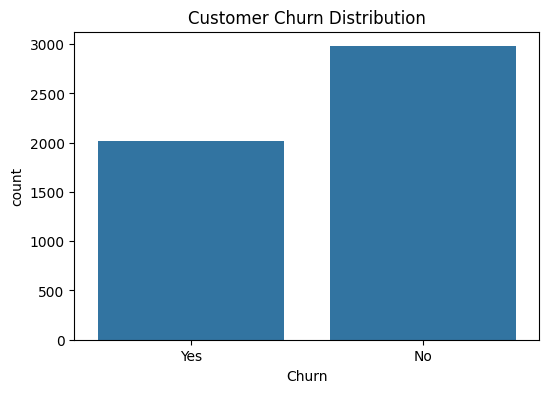

In [6]:
# ==========================
# CHURN DISTRIBUTION
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)
plt.title("Customer Churn Distribution")
plt.savefig("churn_distribution.png")
plt.show()

In [7]:
# ==========================
# CHURN RATE
# ==========================

churn_rate = (
    df['Churn'].value_counts()['Yes']
    / len(df)
) * 100

print(f"\nChurn Rate: {churn_rate:.2f}%")


Churn Rate: 40.44%


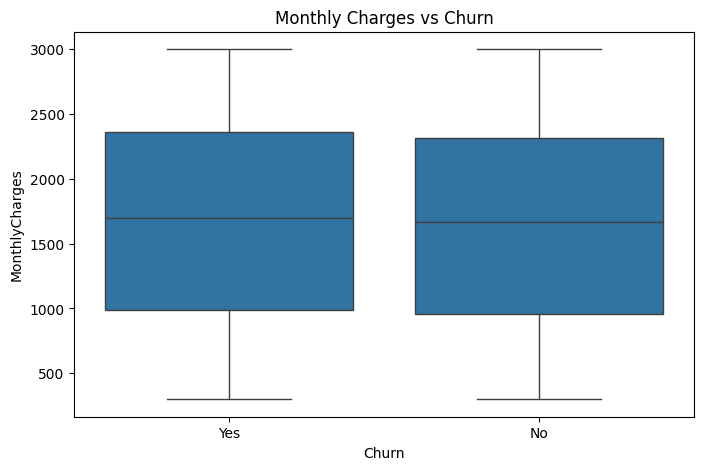

In [8]:
# ==========================
# MONTHLY CHARGES VS CHURN
# ==========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.savefig("monthly_charges_vs_churn.png")
plt.show()

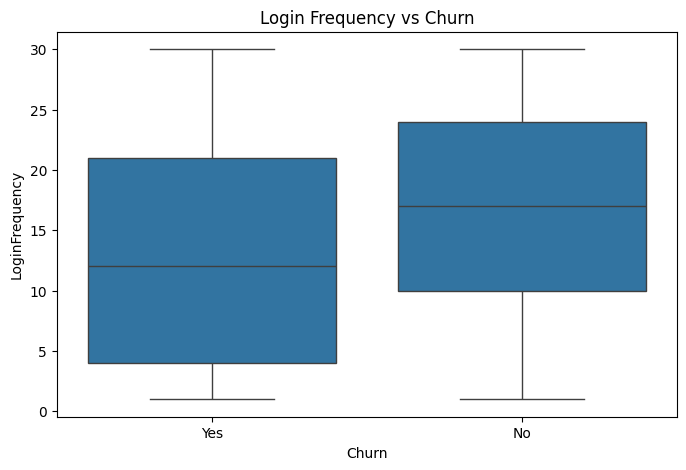

In [9]:
# ==========================
# LOGIN FREQUENCY VS CHURN
# ==========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='LoginFrequency',
    data=df
)

plt.title("Login Frequency vs Churn")
plt.savefig("login_frequency_vs_churn.png")
plt.show()

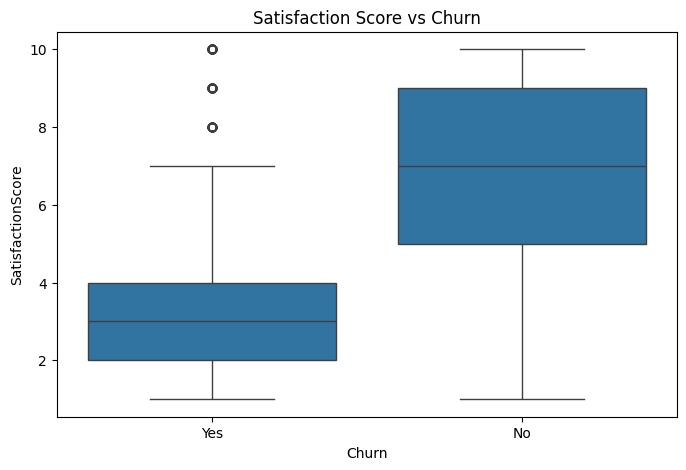

In [10]:
# ==========================
# SATISFACTION VS CHURN
# ==========================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='SatisfactionScore',
    data=df
)

plt.title("Satisfaction Score vs Churn")
plt.savefig("satisfaction_vs_churn.png")
plt.show()

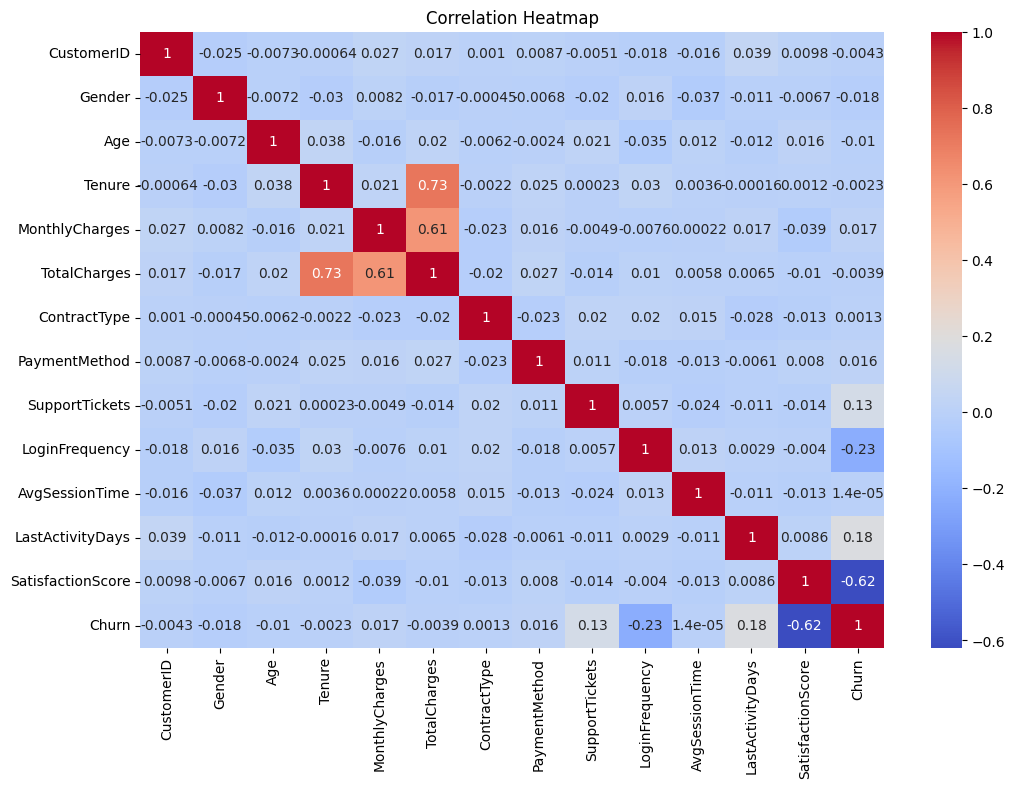

In [11]:
# ==========================
# CORRELATION HEATMAP
# ==========================

temp_df = df.copy()

encoder = LabelEncoder()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = encoder.fit_transform(temp_df[col])

plt.figure(figsize=(12,8))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

In [12]:
# ==========================
# MACHINE LEARNING
# ==========================

ml_df = df.copy()

label_columns = ml_df.select_dtypes(include='object').columns

for col in label_columns:
    ml_df[col] = encoder.fit_transform(ml_df[col])

In [13]:
# ==========================
# FEATURES & TARGET
# ==========================

X = ml_df.drop("Churn", axis=1)

y = ml_df["Churn"]

In [14]:
# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
# ==========================
# LOGISTIC REGRESSION
# ==========================

print("\n===================")
print("LOGISTIC REGRESSION")
print("===================")

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)


LOGISTIC REGRESSION
Accuracy: 0.836

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       604
           1       0.81      0.77      0.79       396

    accuracy                           0.84      1000
   macro avg       0.83      0.82      0.83      1000
weighted avg       0.84      0.84      0.84      1000


Confusion Matrix
[[533  71]
 [ 93 303]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# ==========================
# RANDOM FOREST
# ==========================

print("\n===================")
print("RANDOM FOREST")
print("===================")

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred
    )
)


RANDOM FOREST
Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       604
           1       1.00      1.00      1.00       396

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000




Top Important Features
              Feature  Importance
12  SatisfactionScore    0.547205
9      LoginFrequency    0.189688
11   LastActivityDays    0.106601
8      SupportTickets    0.065456
10     AvgSessionTime    0.015246
0          CustomerID    0.014917
4      MonthlyCharges    0.014599
5        TotalCharges    0.013890
2                 Age    0.011524
3              Tenure    0.011522
7       PaymentMethod    0.004087
6        ContractType    0.003256
1              Gender    0.002009


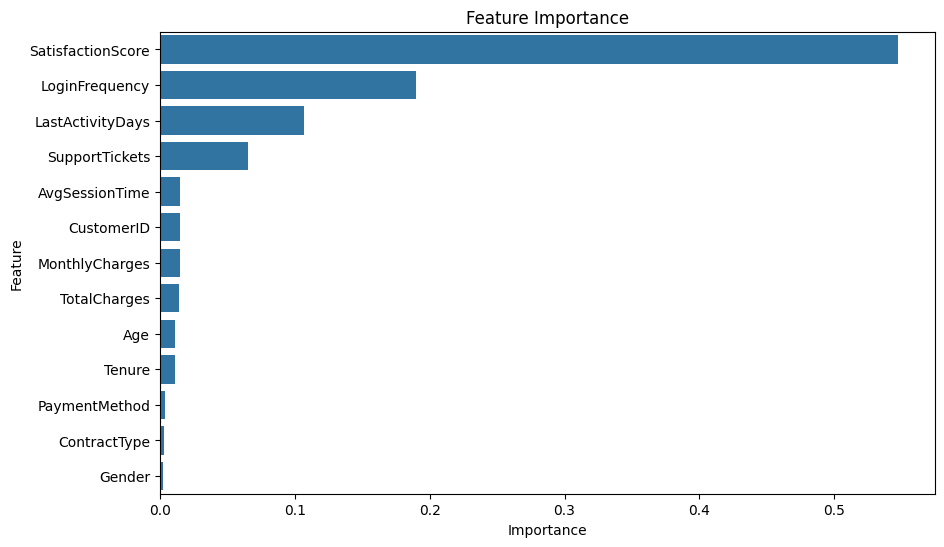

In [17]:
# ==========================
# FEATURE IMPORTANCE
# ==========================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features")
print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

In [18]:
# ==========================
# SAVE CLEAN DATA
# ==========================

df.to_csv(
    "clean_customer_churn.csv",
    index=False
)

print("\nClean Dataset Saved")


Clean Dataset Saved


In [19]:
# ==========================
# BUSINESS INSIGHTS
# ==========================

print("\n===== BUSINESS INSIGHTS =====")

print("""
1. Customers with low login frequency
   are more likely to churn.

2. Low satisfaction score strongly
   impacts churn.

3. High inactivity period is a major
   churn indicator.

4. Customers raising many support
   tickets have higher churn risk.

5. Retention campaigns should target:
   - Low engagement users
   - Unsatisfied customers
   - Inactive customers
""")


===== BUSINESS INSIGHTS =====

1. Customers with low login frequency
   are more likely to churn.

2. Low satisfaction score strongly
   impacts churn.

3. High inactivity period is a major
   churn indicator.

4. Customers raising many support
   tickets have higher churn risk.

5. Retention campaigns should target:
   - Low engagement users
   - Unsatisfied customers
   - Inactive customers

